# Make sure to have "Quotes.csv" to run this notebook.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

def get_bid_ask(file_path):
    quotes = []
    with open(file_path, 'r') as f:
        import csv
        reader = csv.reader(f)
        for row in reader:
            if len(row) >= 3:
                quotes.append([float(row[0]), float(row[2]), float(row[1])])
    return np.array(quotes)

def load_c_values(R1, R2, S0, theta):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0/sigs1[0]), np.exp(dist0/sigs1[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * np.exp(-dist/sigs1[j+1]), 0.5 * (P + sigs1[j+1]*S) * np.exp(dist/sigs1[j+1])))
    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u/sigs2[-1]), -np.exp(-dist_u/sigs2[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * np.exp(dist/sigs2[j-1]), 0.5 * (P + sigs2[j-1]*S) * np.exp(-dist/sigs2[j-1]))
    v1, Dk_v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1], (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2, Dk_v2 = c_v2_unit[0][0] + c_v2_unit[0][1], (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = (Dk_v1 * v2 - v1 * Dk_v2)
    lam1, lam2 = v2 / denom, v1 / denom
    c_v1 = np.array(c_v1_unit) * lam1
    c_v2 = np.array(c_v2_unit) * lam2
    return c_v1, c_v2

def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except:
        return False

    K_vec = bid_ask_arr[:, 0]
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    mask_left = K_vec <= S0
    mask_right = ~mask_left
    results = np.zeros_like(K_vec)

    if np.any(mask_left):
        K_left = K_vec[mask_left]
        indices = np.searchsorted(nus1_full, K_left, side='left') - 1
        indices = np.clip(indices, 0, R1 - 1)
        dist = nus1_full[indices + 1] - K_left
        results[mask_left] = (c_v1[indices, 0] * np.exp(dist/sigs1[indices]) + c_v1[indices, 1] * np.exp(-dist/sigs1[indices])) + S0 - K_left

    if np.any(mask_right):
        K_right = K_vec[mask_right]
        indices = np.searchsorted(nus2_full, K_right, side='left') - 1
        indices = np.clip(indices, 0, R2 - 1)
        dist = K_right - nus2_full[indices]
        results[mask_right] = (c_v2[indices, 0] * np.exp(-dist/sigs2[indices]) + c_v2[indices, 1] * np.exp(dist/sigs2[indices]))

    return np.all((results >= bid_ask_arr[:, 1]) & (results <= bid_ask_arr[:, 2]))

# The Main Algorithm: Coordinate Descent

Instead of using the full gradient of J or some other adjacent objective, coordinate descent minimizes the function along one variable at each iteration.

In this case, our objective is: $$O(θ) = ∑_{i=1}^{R-1} (σ_i - σ_{i+1})^2$$

Although this is considerably different from our original objective J, its benefits more than make up in the power of this algorithm, in major part due to its **simplicity**.

Namely:


*   Minimizing this objective still has the same effect as minimizing J, as adjacent sigmas closer together mean smaller jumps in C".
*   Varying solely sigmas simplifies the dimensionality of the optimization problem, and as we'll see does not compromise in performance.
*   No gradient calculation is needed. It's clear than in one coordinate, the optimal value of $σ_i$ is simply $\frac{σ_{i+1} - σ_{i-1}}{2}$, i.e. minimum is attained exactly in between its neighbors. Another major speed-up since we can use Numpy instead of Pytorch.
*  The only constraint we have to check are bid-ask ranges. By nature of this algorithm, all sigmas are strictly positive if they begin strictly positive. Of course, nus are untouched.


# How it works

At each step, we choose a variable $σ_i$. We then initiate a step in this coordinate, exactly $$d = \frac{σ_{i+1} - σ_{i-1}}{2} - σ_i$$
We then proceed by bisection, checking bid-ask constraints, and bisecting the step length if they don't hold. The objective will **always decrease** since it is convex.

The exact $σ_i$ we choose is still arbitrary. Right now, its implemented as cyclic coordinate descent(CCD), where we simply go through the coordinates sequentially, looping back if we reach the end.

You can also choose a uniformly random $σ_i$, as so-called random coordinate descent(RCD), a form of stochastic gradient descent.

On this particular market data, CCD seems to work better than the average RCD run, I'd like to verify this with other datasets.







In [26]:
def newObjective(sigs):
    return np.sum(np.diff(sigs)**2)


def coordinateDescent(R1, R2, S0, init_theta, bid_ask_arr, num_iterations = 2500):
    theta = init_theta.copy()
    # randperm = np.random.permutation(R1 + R2)

    for i in range(num_iterations):
        sigs1 = theta[R1 : 2 * R1]
        sigs2 = theta[2 * R1 + R2 :]
        sigs = np.concatenate([sigs1, sigs2])

        if i % 1000 == 0:
            current_loss = newObjective(sigs)
            print(f"Iteration {i}/{num_iterations} | Loss: {current_loss:.6f}")

        grad_sigs = np.zeros_like(sigs)
        diffs = np.diff(sigs)
        grad_sigs[:-1] += 0.5 * diffs
        grad_sigs[1:] -= 0.5 * diffs
        grad_sigs[0] = 0.5 * diffs[0]
        grad_sigs[-1] = -0.5 * diffs[-1]
        # index = np.random.randint(0, R1 + R2)
        # index = randperm[i % (R1 + R2)]
        index = i % (R1 + R2)
        if grad_sigs[index] == 0:
            continue
        update_vector = np.zeros_like(theta)
        if index < R1: update_vector[R1 + index] = grad_sigs[index]
        else: update_vector[2 * R1 + R2 + (index - R1)] = grad_sigs[index]
        curr_alpha = 1.0
        for b in range(5):
            test_theta = theta + curr_alpha * update_vector
            if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr):
                theta = test_theta
                break
            curr_alpha *= 0.5
    return theta

In [27]:
# Diagnostic Functions

def C_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    if K <= S0:
        nus1_full = np.concatenate([nus1, [S0]])
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index])) + S0 - K
    else:
        nus2_full = np.concatenate([[S0], nus2])
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def C2_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])

    if K <= S0:
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (1/sigs1[index]**2) * (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index]))
    else:
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (1/sigs2[index]**2) * (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def calculate_J(R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    jumps = []
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j, 0] + c_v1[j, 1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1, 0]*np.exp(dist/sigs1[j+1]) + c_v1[j+1, 1]*np.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1, 0] + c_v1[-1, 1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0, 0] + c_v2[0, 1])
    jumps.append(v2_S0 - v1_S0)
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1, 0] + c_v2[j+1, 1])
        dist = nus2_full[j+1] - nus2_full[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j, 0]*np.exp(-dist/sigs2[j]) + c_v2[j, 1]*np.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
    return np.sum(np.array(jumps) ** 2)

# Here, we optimize market data from the original LVG calibration with coordinate descent. You can really see the speed of the algorithm--with 20,000 iterations it only takes 21 seconds.

Iteration 0/20000 | Loss: 266648.797024
Iteration 1000/20000 | Loss: 2269.046633
Iteration 2000/20000 | Loss: 783.869392
Iteration 3000/20000 | Loss: 515.718340
Iteration 4000/20000 | Loss: 369.286588
Iteration 5000/20000 | Loss: 281.100879
Iteration 6000/20000 | Loss: 226.269620
Iteration 7000/20000 | Loss: 179.621291
Iteration 8000/20000 | Loss: 147.377723
Iteration 9000/20000 | Loss: 120.309664
Iteration 10000/20000 | Loss: 99.874901
Iteration 11000/20000 | Loss: 85.894225
Iteration 12000/20000 | Loss: 73.420383
Iteration 13000/20000 | Loss: 63.654570
Iteration 14000/20000 | Loss: 56.677452
Iteration 15000/20000 | Loss: 50.184069
Iteration 16000/20000 | Loss: 45.079133
Iteration 17000/20000 | Loss: 40.453607
Iteration 18000/20000 | Loss: 36.659468
Iteration 19000/20000 | Loss: 33.699532


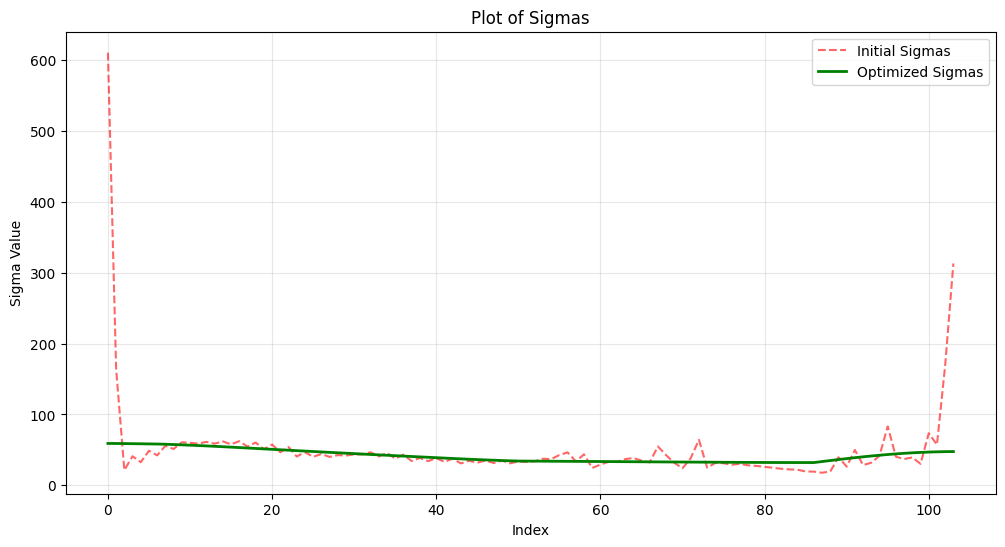

In [28]:
# Model constants
S0 = 1271.87
R1, R2 = 70, 34

# Load market data into NumPy
market_bid_ask = get_bid_ask('Quotes.csv')

# Initial parameters (Converted from your previous lists)
initial_nus1 = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_sigs1 = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_nus2 = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])
initial_sigs2 = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])

init_theta = np.concatenate([initial_nus1, initial_sigs1, initial_nus2, initial_sigs2])

# Run Optimization
opt_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, num_iterations= 20000)

# Visualize Results
init_sigs = np.concatenate([initial_sigs1, initial_sigs2])
opt_sigs = np.concatenate([opt_theta[R1:2*R1], opt_theta[2*R1+R2:]])

plt.figure(figsize=(12, 6))
plt.plot(init_sigs, 'r--', alpha=0.6, label='Initial Sigmas')
plt.plot(opt_sigs, 'g-', linewidth=2, label='Optimized Sigmas')
plt.title('Plot of Sigmas')
plt.xlabel('Index')
plt.ylabel('Sigma Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Even though the objective is different, it still minimizes J to a crazy degree. Here we print reduction in the original objective J.

In [29]:
# Calculate J for initial parameters
c_v1_init, c_v2_init = load_c_values(R1, R2, S0, init_theta)
j_init = calculate_J(R1, R2, S0, init_theta, c_v1_init, c_v2_init)

# Calculate J for optimized parameters
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)
j_opt = calculate_J(R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt)

# Calculate percent reduction
reduction = (j_init - j_opt) / j_init * 100

print(f"Initial J (Jump Metric): {j_init:.8f}")
print(f"Final J (Jump Metric):   {j_opt:.8f}")
print(f"Percent Reduction in J:  {reduction:.2f}%")

Initial J (Jump Metric): 0.00125289
Final J (Jump Metric):   0.00000060
Percent Reduction in J:  99.95%


# A plot of C(K), along with bid-ask ranges.

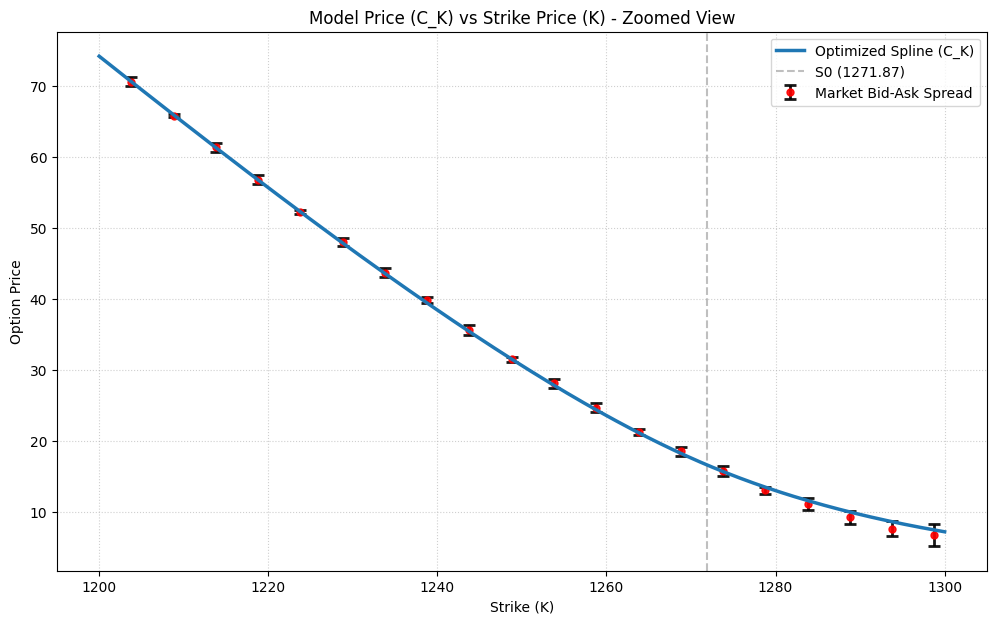

In [30]:
# 1. Define the range for K
nus1 = opt_theta[0:R1]
nus2 = opt_theta[2*R1 : 2*R1 + R2]

k_min = 1200
k_max = 1300

# Generate a smooth range of K values for the model line
K_plot = np.linspace(k_min, k_max, 500)

# 2. Pre-calculate c_v values
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

# 3. Calculate model prices
model_prices = np.array([C_K(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_plot])

# 4. Filter market data
mask = (market_bid_ask[:, 0] >= k_min) & (market_bid_ask[:, 0] <= k_max)
market_subset = market_bid_ask[mask]

strikes = market_subset[:, 0]
bids = market_subset[:, 1]
asks = market_subset[:, 2]
mid_prices = (bids + asks) / 2
yerr = [(mid_prices - bids), (asks - mid_prices)]

# 5. Plotting with enhanced error bars
plt.figure(figsize=(12, 7))

# Plot the spline model
plt.plot(K_plot, model_prices, color='#1f77b4', label='Optimized Spline (C_K)', linewidth=2.5, zorder=3)

# Add more apparent market bid-ask error bars
plt.errorbar(strikes, mid_prices, yerr=yerr, fmt='o', color='red',
             ecolor='black', elinewidth=2, capsize=4, capthick=2, markersize=5,
             label='Market Bid-Ask Spread', alpha=0.9, zorder=2)

plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')
plt.title('Model Price (C_K) vs Strike Price (K) - Zoomed View')
plt.xlabel('Strike (K)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# A plot of C"(K). Major jumps are no more. It's shape is quite interesting, as if the optimal shape is 2 exponentials. Don't really know why this is.

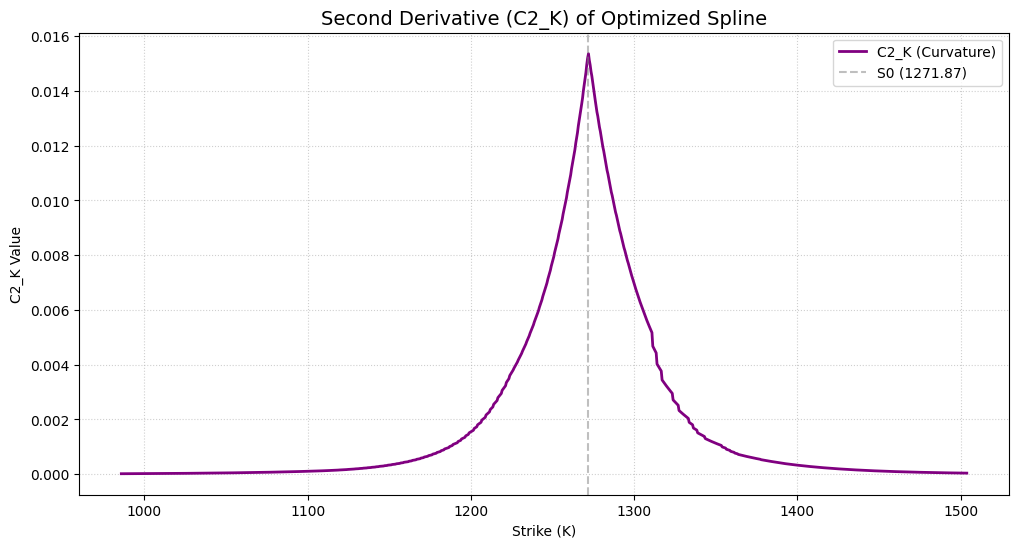

In [31]:
# 1. Pre-calculate c_v values for the optimized theta
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

# 2. Extract the range from nus[1] to nus2[-2]
nus1 = opt_theta[0:R1]
nus2 = opt_theta[2*R1 : 2*R1 + R2]
k_min_plot = nus1[1]
k_max_plot = nus2[-2]

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 1000)
c2_values = np.array([C2_K(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values, color='purple', linewidth=2, label='C2_K (Curvature)')
plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')

plt.title('Second Derivative (C2_K) of Optimized Spline', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('C2_K Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Here, we run the algorithm 5 times and plot the results. Switch algo to RCD before viewing. They seem to converge to a similar theta, however some trials may end up getting stuck.

Starting 5 independent optimization runs (10k iterations each)...
Run 1/5...
Iteration 0/20000 | Loss: 266648.797024
Iteration 1000/20000 | Loss: 2269.046633
Iteration 2000/20000 | Loss: 783.869392
Iteration 3000/20000 | Loss: 515.718340
Iteration 4000/20000 | Loss: 369.286588
Iteration 5000/20000 | Loss: 281.100879
Iteration 6000/20000 | Loss: 226.269620
Iteration 7000/20000 | Loss: 179.621291
Iteration 8000/20000 | Loss: 147.377723
Iteration 9000/20000 | Loss: 120.309664
Iteration 10000/20000 | Loss: 99.874901
Iteration 11000/20000 | Loss: 85.894225
Iteration 12000/20000 | Loss: 73.420383
Iteration 13000/20000 | Loss: 63.654570
Iteration 14000/20000 | Loss: 56.677452
Iteration 15000/20000 | Loss: 50.184069
Iteration 16000/20000 | Loss: 45.079133
Iteration 17000/20000 | Loss: 40.453607
Iteration 18000/20000 | Loss: 36.659468
Iteration 19000/20000 | Loss: 33.699532
  > Final Loss: 30.850671
Run 2/5...
Iteration 0/20000 | Loss: 266648.797024
Iteration 1000/20000 | Loss: 2269.046633
Iter

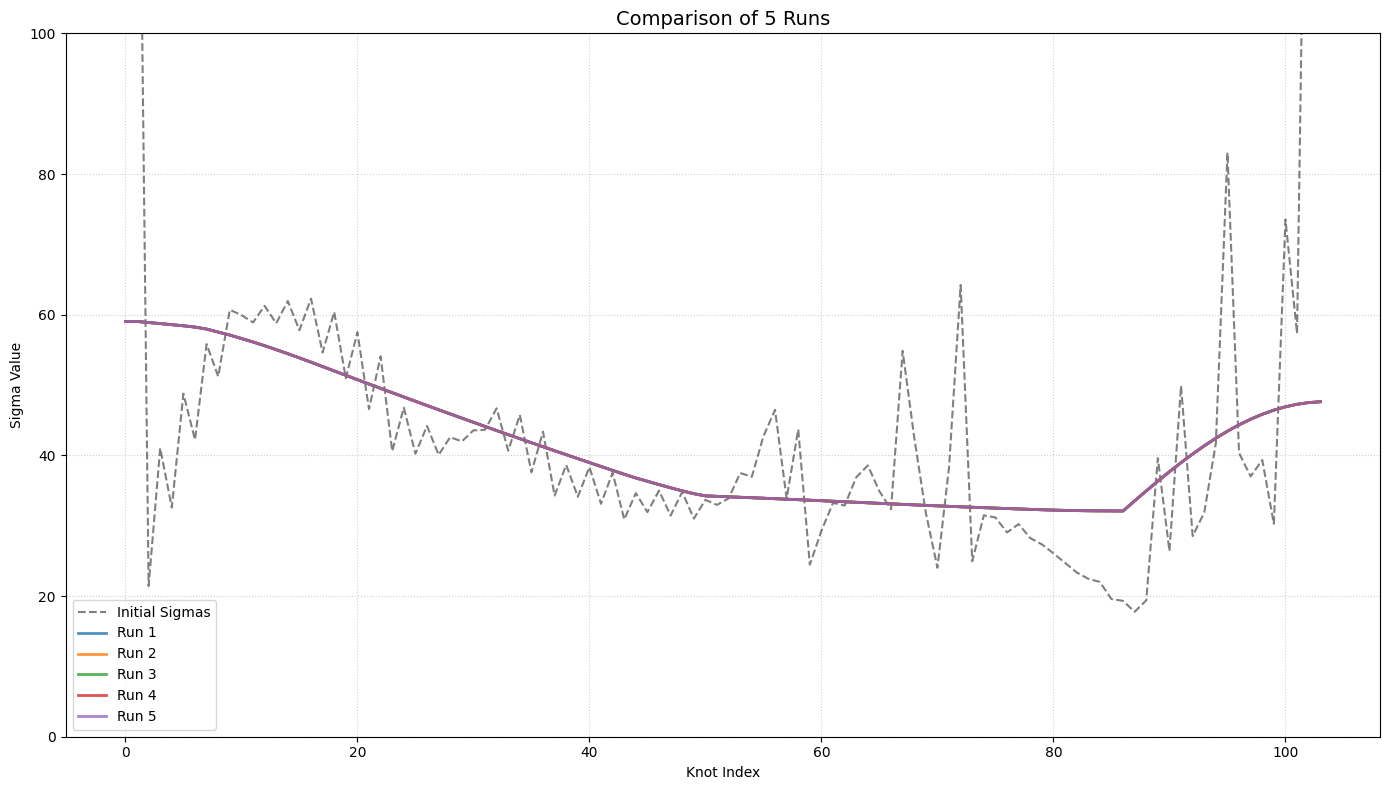

In [32]:
num_runs = 5
multi_run_results = []

print(f"Starting {num_runs} independent optimization runs (10k iterations each)...")
for r in range(num_runs):
    print(f"Run {r+1}/{num_runs}...")
    res_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, num_iterations=20000)

    res_sigs = np.concatenate([res_theta[R1:2*R1], res_theta[2*R1+R2:]])
    final_loss = newObjective(res_sigs)
    multi_run_results.append(res_sigs)
    print(f"  > Final Loss: {final_loss:.6f}")

# Plotting
plt.figure(figsize=(14, 8))
plt.plot(init_sigs, 'k--', alpha=0.5, label='Initial Sigmas', linewidth=1.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, sigs in enumerate(multi_run_results):
    plt.plot(sigs, color=colors[i], alpha=0.8, linewidth=2, label=f'Run {i+1}')
plt.title('Comparison of 5 Runs', fontsize=14)
plt.xlabel('Knot Index')
plt.ylabel('Sigma Value')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# If you run coordinate descent for enough iterations, it eventually stalls and doesn't make improvement. As the sigmas gets closer together, subsequent iterations move each coordinate less. Of course, constraints may also bottleneck improvement.

# I am curious though if optimization with gradient-based could be applied after this algo to make further progress.


# Local follow-up: plots and gradient-descent continuation

This section is intentionally local. It does not change the cyclic coordinate descent algorithm above.

The goals are:

1. Replot the time-value curve \(V(K)=C(K)-\max(S_0-K,0)\) for the original LVG theta and the CCD theta.
2. Replot the piecewise diffusion coefficient, meaning the sigma assigned to each LVG strike interval.
3. Recompute the original jump objective \(J\) at the CCD theta.
4. Start a simple sigma-only gradient-descent continuation from the CCD theta to test whether the original \(J\) can be improved further.


In [33]:

# Helper functions for the follow-up plots.
# These use the same LVG functions already defined above: load_c_values, C_K, C2_K, calculate_J.

def get_theta_parts_numpy(theta):
    left_nu = theta[0:R1]
    left_sigma = theta[R1:2 * R1]
    right_nu = theta[2 * R1:2 * R1 + R2]
    right_sigma = theta[2 * R1 + R2:]
    return left_nu, left_sigma, right_nu, right_sigma


def call_curve(theta, K_values):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    prices = []
    for K in K_values:
        prices.append(C_K(K, R1, R2, S0, theta, c_v1, c_v2))
    return np.array(prices)


def time_value_curve(theta, K_values):
    call_prices = call_curve(theta, K_values)
    intrinsic = np.maximum(S0 - K_values, 0.0)
    return call_prices - intrinsic


def plot_time_value_curves(theta_initial, theta_ccd, k_min=1100, k_max=1390):
    K_plot = np.linspace(k_min, k_max, 600)
    V_initial = time_value_curve(theta_initial, K_plot)
    V_ccd = time_value_curve(theta_ccd, K_plot)

    plt.figure(figsize=(11, 6))
    plt.plot(K_plot, V_initial, color="blue", linewidth=2, label="baseline LVG")
    plt.plot(K_plot, V_ccd, color="green", linewidth=2, label="CCD theta")
    plt.axvline(S0, color="black", linestyle=":", linewidth=1, label="S0")
    plt.xlabel("K")
    plt.ylabel("time value V(K)")
    plt.title("Time value curve before and after CCD")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_call_curves(theta_initial, theta_ccd, k_min=1100, k_max=1390):
    K_plot = np.linspace(k_min, k_max, 600)
    C_initial = call_curve(theta_initial, K_plot)
    C_ccd = call_curve(theta_ccd, K_plot)

    plt.figure(figsize=(11, 6))
    plt.plot(K_plot, C_initial, color="blue", linewidth=2, label="baseline LVG")
    plt.plot(K_plot, C_ccd, color="green", linewidth=2, label="CCD theta")
    plt.axvline(S0, color="black", linestyle=":", linewidth=1, label="S0")
    plt.xlabel("K")
    plt.ylabel("call price C(K)")
    plt.title("Call price curve before and after CCD")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def sigma_step_data(theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts_numpy(theta)
    left_grid = np.concatenate([left_nu, [S0]])
    right_grid = np.concatenate([[S0], right_nu])

    x_values = []
    y_values = []

    for i in range(R1):
        K_left = left_grid[i]
        K_right = left_grid[i + 1]
        if K_left <= 0 or K_right <= 0:
            continue
        x_values.extend([np.log(K_left / S0), np.log(K_right / S0)])
        y_values.extend([left_sigma[i], left_sigma[i]])

    for i in range(R2):
        K_left = right_grid[i]
        K_right = right_grid[i + 1]
        if K_left <= 0 or K_right <= 0:
            continue
        x_values.extend([np.log(K_left / S0), np.log(K_right / S0)])
        y_values.extend([right_sigma[i], right_sigma[i]])

    return np.array(x_values), np.array(y_values)


def plot_sigma_coefficients(theta_initial, theta_ccd, x_min=-0.06, x_max=0.06, y_max=90):
    x_initial, y_initial = sigma_step_data(theta_initial)
    x_ccd, y_ccd = sigma_step_data(theta_ccd)

    plt.figure(figsize=(12, 6))
    plt.plot(x_initial, y_initial, color="blue", linewidth=1.5, label="baseline LVG")
    plt.plot(x_ccd, y_ccd, color="green", linewidth=2.0, label="CCD theta")
    plt.axvline(0, color="black", linewidth=1)
    plt.xlim(x_min, x_max)
    plt.ylim(0, y_max)
    plt.xlabel("log(K / S0)")
    plt.ylabel("diffusion coefficient sigma")
    plt.title("Piecewise diffusion coefficient before and after CCD")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


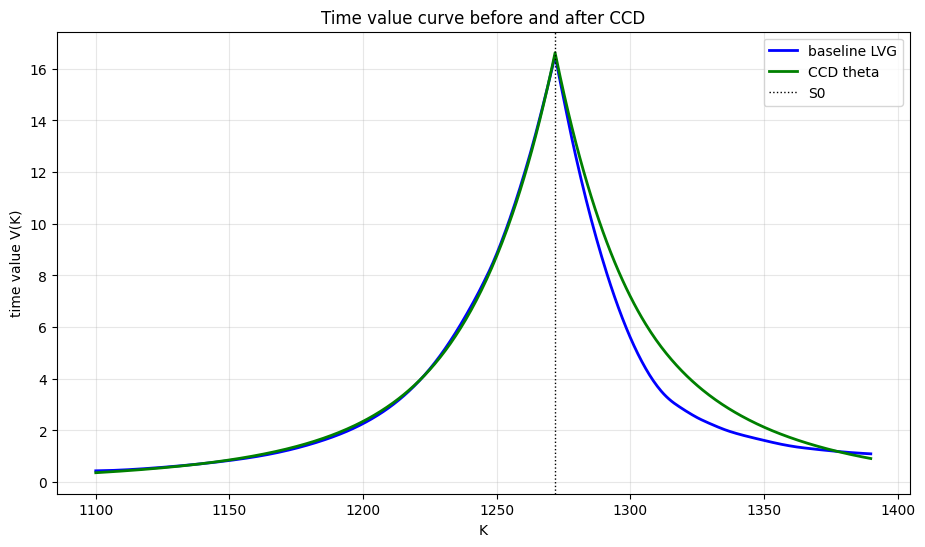

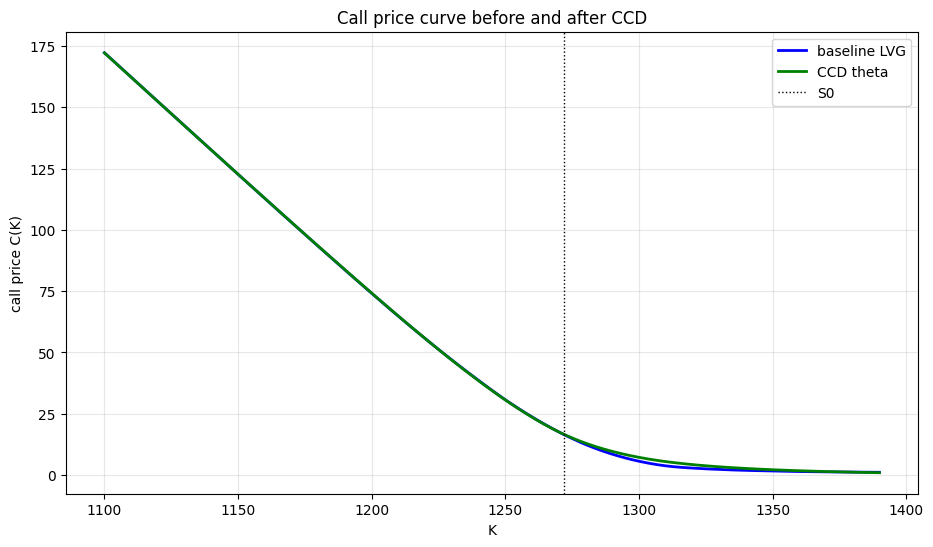

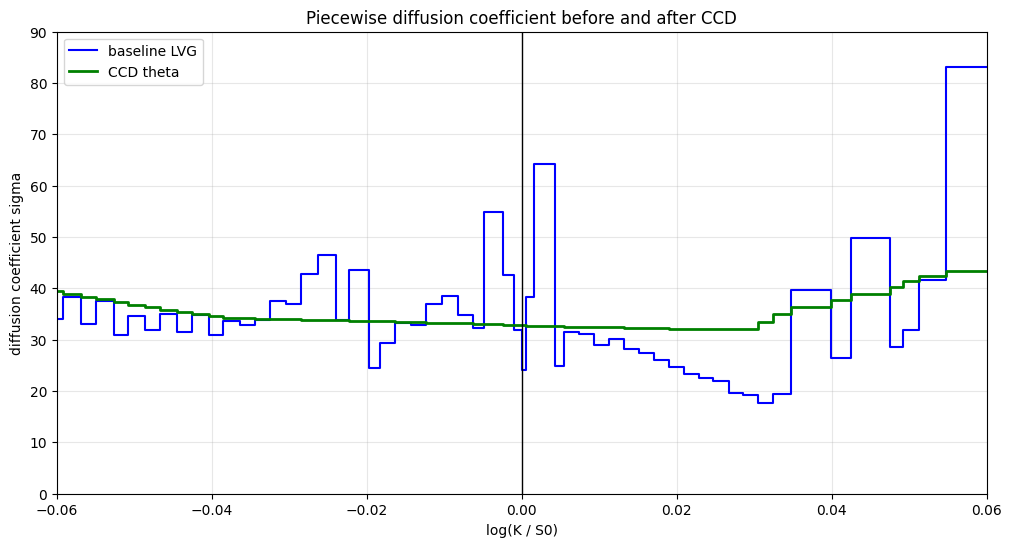

In [34]:

# Reproduce the main curves from our earlier notebooks.
# This cell assumes the original CCD cell above has already created init_theta and opt_theta.

plot_time_value_curves(init_theta, opt_theta)
plot_call_curves(init_theta, opt_theta)
plot_sigma_coefficients(init_theta, opt_theta)


In [35]:

# Confirm the original jump objective J at the baseline theta and at the CCD theta.

c_v1_initial, c_v2_initial = load_c_values(R1, R2, S0, init_theta)
J_initial = calculate_J(R1, R2, S0, init_theta, c_v1_initial, c_v2_initial)

c_v1_ccd, c_v2_ccd = load_c_values(R1, R2, S0, opt_theta)
J_ccd = calculate_J(R1, R2, S0, opt_theta, c_v1_ccd, c_v2_ccd)

print("Baseline J:", J_initial)
print("CCD J:", J_ccd)
print("Percent reduction:", 100.0 * (J_initial - J_ccd) / J_initial)
print("CCD bid-ask feasible:", validate_and_check_market(R1, R2, S0, opt_theta, market_bid_ask))


Baseline J: 0.0012528863458905063
CCD J: 5.978597035655093e-07
Percent reduction: 99.9522814096006
CCD bid-ask feasible: True



## Sigma-only gradient descent starting from the CCD theta

This next block tests whether CCD has already reached a point where the original jump objective \(J\) cannot be improved much by moving sigmas only.

To keep this notebook independent of PyTorch, the gradient is computed by finite differences. That is slower than automatic differentiation, but it is very easy to explain:

\[
\frac{\partial J}{\partial \sigma_i}
\approx
\frac{J(\sigma_i+h)-J(\sigma_i-h)}{2h}.
\]

Then we try:

\[
\theta_{new}=\theta-\alpha \nabla_\sigma J.
\]

A proposed step is accepted only if:

1. all sigmas remain positive,
2. the model remains inside bid-ask,
3. the original jump objective \(J\) decreases.

If a step fails, the step size is cut in half.


In [36]:

# PyTorch sigma-only gradient descent from the CCD theta.
# This optimizes the original jump objective J, not the CCD proxy objective.
# It changes only sigmas. The nus remain fixed.


def theta_to_torch(theta):
    return torch.tensor(theta, dtype=torch.float64)


def torch_lvg_coefficients(R1, R2, S0, theta):
    idx = 0
    nus1 = theta[idx:idx + R1]
    idx += R1
    sigs1 = theta[idx:idx + R1]
    idx += R1
    nus2 = theta[idx:idx + R2]
    idx += R2
    sigs2 = theta[idx:idx + R2]

    S0_t = torch.tensor(S0, dtype=torch.float64)
    nus1_full = torch.cat([nus1, S0_t.reshape(1)])
    nus2_full = torch.cat([S0_t.reshape(1), nus2])

    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append(torch.stack([
        -torch.exp(-dist0 / sigs1[0]),
        torch.exp(dist0 / sigs1[0]),
    ]))

    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        slope = (-c_v1_unit[j][0] + c_v1_unit[j][1]) / sigs1[j]
        dist = nus1_full[j + 2] - nus1_full[j + 1]
        next_left = 0.5 * (P - sigs1[j + 1] * slope) * torch.exp(-dist / sigs1[j + 1])
        next_right = 0.5 * (P + sigs1[j + 1] * slope) * torch.exp(dist / sigs1[j + 1])
        c_v1_unit.append(torch.stack([next_left, next_right]))

    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = torch.stack([
        torch.exp(dist_u / sigs2[-1]),
        -torch.exp(-dist_u / sigs2[-1]),
    ])

    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        slope = (-c_v2_unit[j][0] + c_v2_unit[j][1]) / sigs2[j]
        dist = nus2_full[j] - nus2_full[j - 1]
        next_left = 0.5 * (P - sigs2[j - 1] * slope) * torch.exp(dist / sigs2[j - 1])
        next_right = 0.5 * (P + sigs2[j - 1] * slope) * torch.exp(-dist / sigs2[j - 1])
        c_v2_unit[j - 1] = torch.stack([next_left, next_right])

    c_v1_unit = torch.stack(c_v1_unit)
    c_v2_unit = torch.stack(c_v2_unit)

    v1 = c_v1_unit[-1, 0] + c_v1_unit[-1, 1]
    Dk_v1 = (-c_v1_unit[-1, 0] + c_v1_unit[-1, 1]) / sigs1[-1]
    v2 = c_v2_unit[0, 0] + c_v2_unit[0, 1]
    Dk_v2 = (-c_v2_unit[0, 0] + c_v2_unit[0, 1]) / sigs2[0]

    denom = Dk_v1 * v2 - v1 * Dk_v2
    lambda_left = v2 / denom
    lambda_right = v1 / denom

    c_v1 = c_v1_unit * lambda_left
    c_v2 = c_v2_unit * lambda_right
    return c_v1, c_v2, lambda_left, lambda_right


def torch_J_from_theta(theta):
    idx = 0
    nus1 = theta[idx:idx + R1]
    idx += R1
    sigs1 = theta[idx:idx + R1]
    idx += R1
    nus2 = theta[idx:idx + R2]
    idx += R2
    sigs2 = theta[idx:idx + R2]

    S0_t = torch.tensor(S0, dtype=torch.float64)
    nus1_full = torch.cat([nus1, S0_t.reshape(1)])
    nus2_full = torch.cat([S0_t.reshape(1), nus2])
    c_v1, c_v2, lambda_left, lambda_right = torch_lvg_coefficients(R1, R2, S0, theta)

    jumps = []

    for j in range(R1 - 1):
        C2_left = (c_v1[j, 0] + c_v1[j, 1]) / (sigs1[j] ** 2)
        dist = nus1_full[j + 2] - nus1_full[j + 1]
        C2_right = (
            c_v1[j + 1, 0] * torch.exp(dist / sigs1[j + 1])
            + c_v1[j + 1, 1] * torch.exp(-dist / sigs1[j + 1])
        ) / (sigs1[j + 1] ** 2)
        jumps.append(C2_right - C2_left)

    C2_left_spot = (c_v1[-1, 0] + c_v1[-1, 1]) / (sigs1[-1] ** 2)
    C2_right_spot = (c_v2[0, 0] + c_v2[0, 1]) / (sigs2[0] ** 2)
    jumps.append(C2_right_spot - C2_left_spot)

    for j in range(R2 - 1):
        dist = nus2_full[j + 1] - nus2_full[j]
        C2_left = (
            c_v2[j, 0] * torch.exp(-dist / sigs2[j])
            + c_v2[j, 1] * torch.exp(dist / sigs2[j])
        ) / (sigs2[j] ** 2)
        C2_right = (c_v2[j + 1, 0] + c_v2[j + 1, 1]) / (sigs2[j + 1] ** 2)
        jumps.append(C2_right - C2_left)

    jumps = torch.stack(jumps)
    return torch.sum(jumps ** 2)


def sigma_vector_from_theta(theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts_numpy(theta)
    return np.concatenate([left_sigma, right_sigma])


def theta_with_new_sigmas(theta, sigma_values):
    theta_new = theta.copy()
    theta_new[R1:2 * R1] = sigma_values[0:R1]
    theta_new[2 * R1 + R2:] = sigma_values[R1:R1 + R2]
    return theta_new


def J_from_theta(theta):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    return calculate_J(R1, R2, S0, theta, c_v1, c_v2)


def sigma_gradient_from_torch(theta_numpy):
    theta = theta_to_torch(theta_numpy)
    theta.requires_grad_(True)

    J_value = torch_J_from_theta(theta)
    J_value.backward()

    full_gradient = theta.grad.detach().numpy()
    sigma_gradient = np.concatenate([
        full_gradient[R1:2 * R1],
        full_gradient[2 * R1 + R2:],
    ])
    return J_value.item(), sigma_gradient


def static_arbitrage_report(theta, k_min=1100, k_max=1390, n_grid=800):
    K_grid = np.linspace(k_min, k_max, n_grid)
    C_grid = call_curve(theta, K_grid)
    V_grid = C_grid - np.maximum(S0 - K_grid, 0.0)

    dK = np.diff(K_grid)
    slopes = np.diff(C_grid) / dK
    curvature = np.diff(slopes)

    monotone_ok = np.all(np.diff(C_grid) <= 1e-8)
    slope_ok = np.all((slopes >= -1.0 - 1e-8) & (slopes <= 1e-8))
    convex_ok = np.all(curvature >= -1e-7)
    positive_time_value_ok = np.all(V_grid >= -1e-7)

    return {
        "monotone_calls": monotone_ok,
        "slope_between_minus_one_and_zero": slope_ok,
        "convex_calls": convex_ok,
        "positive_time_value": positive_time_value_ok,
        "min_time_value": np.min(V_grid),
        "min_slope": np.min(slopes),
        "max_slope": np.max(slopes),
        "min_curvature_change": np.min(curvature),
    }


def print_constraint_report(name, theta):
    sigma = sigma_vector_from_theta(theta)
    c_v1, c_v2, lambda_left, lambda_right = load_c_values(R1, R2, S0, theta)[0], load_c_values(R1, R2, S0, theta)[1], None, None

    print("\n", name)
    print("positive sigmas:", np.all(sigma > 0), "min sigma:", np.min(sigma))
    print("bid-ask feasible:", validate_and_check_market(R1, R2, S0, theta, market_bid_ask))

    report = static_arbitrage_report(theta)
    for key, value in report.items():
        print(key + ":", value)


def gradient_descent_from_theta(start_theta, initial_step_size=1000.0, min_step_size=1e-14):
    theta = start_theta.copy()
    J_history = []
    step_history = []
    iteration = 0

    while True:
        J_old, grad = sigma_gradient_from_torch(theta)
        grad_norm = np.linalg.norm(grad)
        J_history.append(J_old)

        print("Iteration", iteration, "J =", J_old, "gradient norm =", grad_norm)

        if grad_norm == 0 or not np.isfinite(grad_norm):
            print("Stopping because the gradient is zero or not finite.")
            break

        direction = -grad / grad_norm
        sigma_old = sigma_vector_from_theta(theta)
        step_size = initial_step_size
        accepted = False

        while step_size >= min_step_size:
            sigma_new = sigma_old + step_size * direction

            if np.any(sigma_new <= 0):
                step_size *= 0.5
                continue

            theta_new = theta_with_new_sigmas(theta, sigma_new)

            if not validate_and_check_market(R1, R2, S0, theta_new, market_bid_ask):
                step_size *= 0.5
                continue

            J_new = J_from_theta(theta_new)

            if J_new < J_old:
                theta = theta_new
                step_history.append(step_size)
                print("  accepted step", step_size, "new J =", J_new)
                accepted = True
                break

            step_size *= 0.5

        if not accepted:
            print("No feasible improving step found above min_step_size. Stopping.")
            break

        iteration += 1

    return theta, J_history, step_history


print_constraint_report("CCD theta before gradient descent", opt_theta)

theta_after_gd, gd_J_history, gd_step_history = gradient_descent_from_theta(
    opt_theta,
    initial_step_size=1000.0,
    min_step_size=1e-14,
)

J_after_gd = J_from_theta(theta_after_gd)
print("CCD J:", J_ccd)
print("GD-after-CCD J:", J_after_gd)
print("Additional percent reduction from CCD:", 100.0 * (J_ccd - J_after_gd) / J_ccd)
print_constraint_report("GD-after-CCD theta", theta_after_gd)



 CCD theta before gradient descent
positive sigmas: True min sigma: 32.09467022493152
bid-ask feasible: True
monotone_calls: True
slope_between_minus_one_and_zero: True
convex_calls: True
positive_time_value: True
min_time_value: 0.3612303947174951
min_slope: -0.9938623803651686
max_slope: -0.019255615361096757
min_curvature_change: 3.785032935388344e-05
Iteration 0 J = 5.9785970356551e-07 gradient norm = 2.9264518734483873e-07
  accepted step 0.06103515625 new J = 5.809149705855369e-07
Iteration 1 J = 5.809149705855378e-07 gradient norm = 2.6339280747957666e-07
  accepted step 0.0152587890625 new J = 5.769479268669005e-07
Iteration 2 J = 5.769479268669005e-07 gradient norm = 2.566164011299964e-07
  accepted step 0.00762939453125 new J = 5.750027847868918e-07
Iteration 3 J = 5.750027847868939e-07 gradient norm = 2.5330105247907546e-07
  accepted step 0.003814697265625 new J = 5.740396499038901e-07
Iteration 4 J = 5.740396499038889e-07 gradient norm = 2.5166153964596034e-07
  accepted 

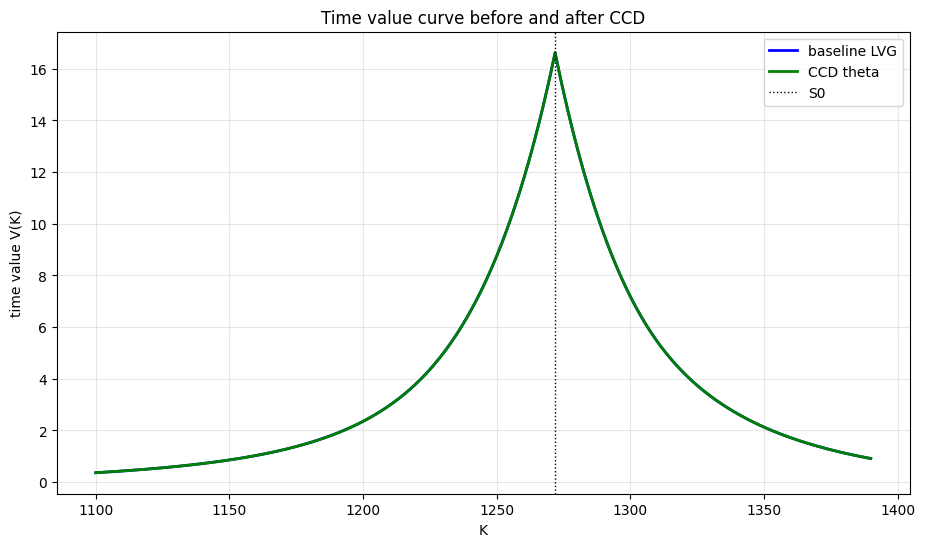

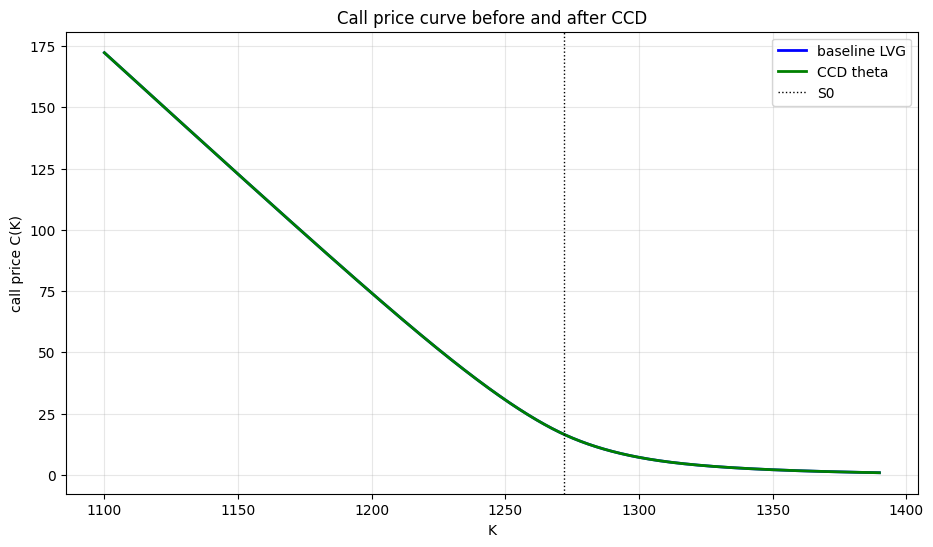

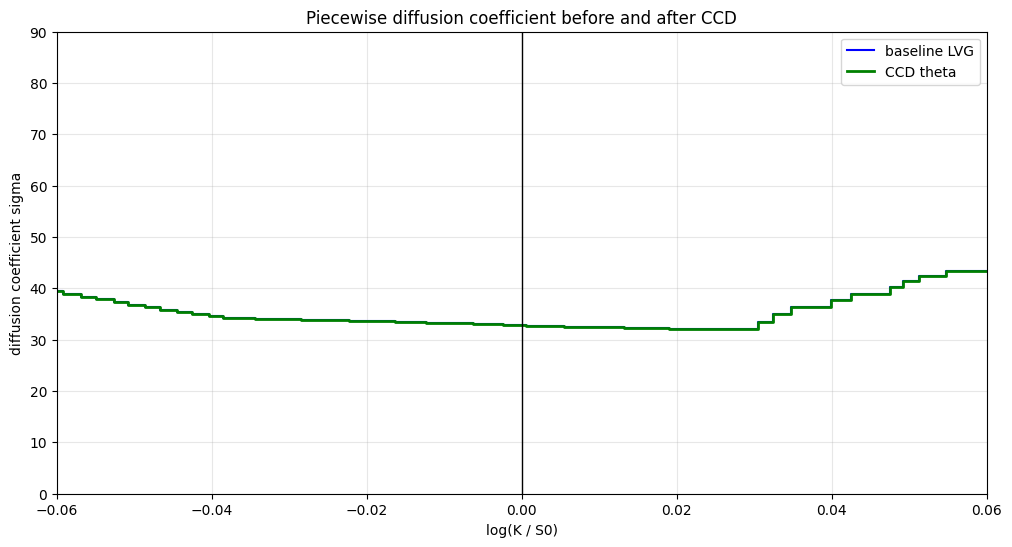

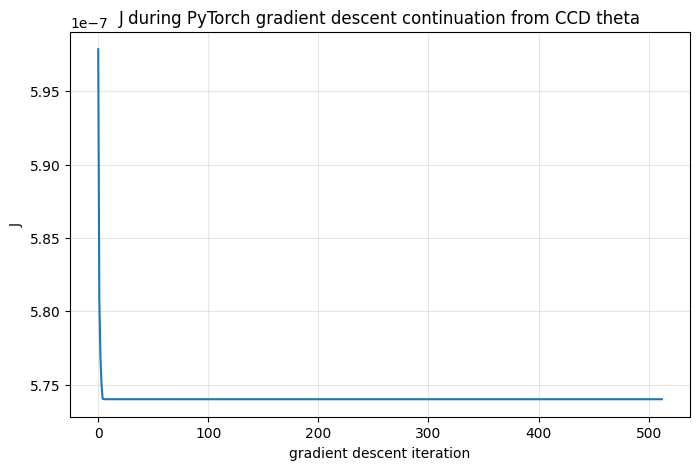

In [37]:

# Compare CCD and gradient-descent-after-CCD curves.

plot_time_value_curves(opt_theta, theta_after_gd)
plot_call_curves(opt_theta, theta_after_gd)
plot_sigma_coefficients(opt_theta, theta_after_gd)

plt.figure(figsize=(8, 5))
plt.plot(gd_J_history)
plt.xlabel("gradient descent iteration")
plt.ylabel("J")
plt.title("J during PyTorch gradient descent continuation from CCD theta")
plt.grid(True, alpha=0.3)
plt.show()


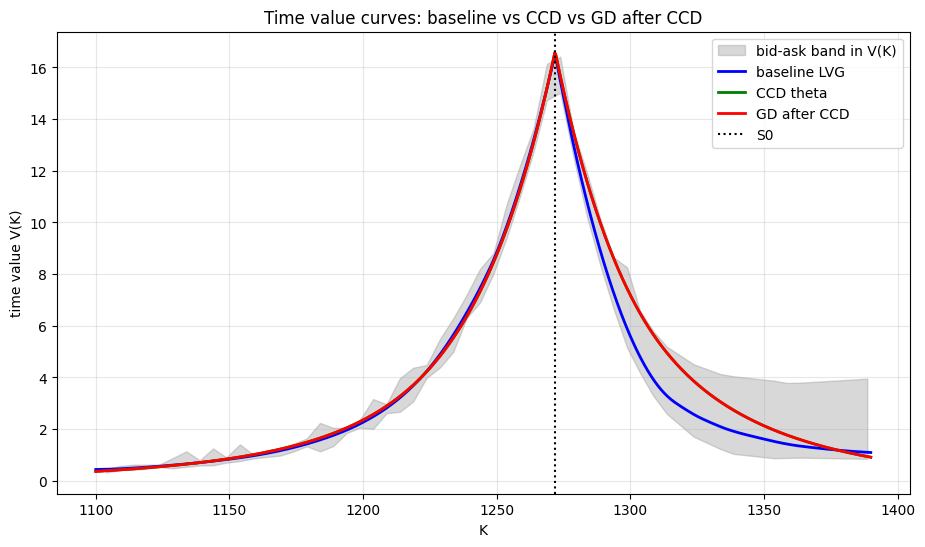

In [38]:
# Time-value comparison: baseline vs CCD vs GD-after-CCD
import pandas as pd
def load_bid_ask_time_value_band(path, S0):
    quotes = pd.read_csv(path, header=None, names=["K", "ask", "bid"])
    quotes = quotes.sort_values("K").reset_index(drop=True)

    K_q = quotes["K"].to_numpy(dtype=float)
    ask_q = quotes["ask"].to_numpy(dtype=float)
    bid_q = quotes["bid"].to_numpy(dtype=float)

    intrinsic_q = np.maximum(S0 - K_q, 0.0)

    V_bid = bid_q - intrinsic_q
    V_ask = ask_q - intrinsic_q

    return K_q, V_bid, V_ask


K_band, V_bid, V_ask = load_bid_ask_time_value_band("Quotes.csv", S0)

K_plot = np.linspace(1100, 1390, 700)

V_baseline = time_value_curve(init_theta, K_plot)
V_ccd = time_value_curve(opt_theta, K_plot)
V_gd_after_ccd = time_value_curve(theta_after_gd, K_plot)

plt.figure(figsize=(11, 6))

plt.fill_between(
    K_band,
    V_bid,
    V_ask,
    color="gray",
    alpha=0.3,
    label="bid-ask band in V(K)"
)

plt.plot(K_plot, V_baseline, color="blue", linewidth=2, label="baseline LVG")
plt.plot(K_plot, V_ccd, color="green", linewidth=2, label="CCD theta")
plt.plot(K_plot, V_gd_after_ccd, color="red", linewidth=2, label="GD after CCD")

plt.axvline(S0, color="black", linestyle=":", linewidth=1.5, label="S0")

plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Time value curves: baseline vs CCD vs GD after CCD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# CCD variant experiment

The original cyclic coordinate descent method updates one sigma at a time in the fixed order

\[
0,1,2,\ldots,n-1,0,1,2,\ldots.
\]

That worked very well, but now we want to know whether the result depends on this exact update order. If the method is robust, several reasonable coordinate orders should lead to similar final values of the true jump objective \(J\).

We test four versions:

1. **Forward cyclic CCD**: update sigmas from left to right.
2. **Reverse cyclic CCD**: update sigmas from right to left.
3. **Shuffled-sweep CCD**: at each sweep, randomly shuffle the coordinates, then update each coordinate once.
4. **Random-coordinate CCD**: at each step, randomly choose one coordinate. Some coordinates may be chosen more than once before others are chosen.

All four variants use the same idea:

- keep all \(\nu\)'s fixed,
- change only sigmas,
- move one sigma in the direction that reduces the adjacent-sigma roughness objective

\[
O(\sigma)=\sum_i (\sigma_{i+1}-\sigma_i)^2,
\]

- accept the move only if the LVG call prices remain inside bid-ask.

After each method finishes, we evaluate the original jump objective \(J\). This is important because CCD is not directly minimizing \(J\); it is minimizing a simpler sigma-smoothness proxy and then we check whether the true LVG jump metric improves.


In [39]:

# Simple utilities for comparing CCD variants.


def get_all_sigmas(theta):
    left_sigmas = theta[R1:2 * R1]
    right_sigmas = theta[2 * R1 + R2:]
    return np.concatenate([left_sigmas, right_sigmas])


def put_all_sigmas(theta, sigmas):
    theta_new = theta.copy()
    theta_new[R1:2 * R1] = sigmas[0:R1]
    theta_new[2 * R1 + R2:] = sigmas[R1:R1 + R2]
    return theta_new


def sigma_proxy_objective(sigmas):
    return np.sum(np.diff(sigmas) ** 2)


def sigma_smoothing_direction(sigmas):
    # This is the coordinate-wise direction used by the original CCD notebook.
    # It points each sigma toward the average of its neighbors.
    direction = np.zeros_like(sigmas)
    diffs = np.diff(sigmas)

    direction[:-1] += 0.5 * diffs
    direction[1:] -= 0.5 * diffs

    direction[0] = 0.5 * diffs[0]
    direction[-1] = -0.5 * diffs[-1]

    return direction


def model_prices_at_quotes(theta):
    strikes = market_bid_ask[:, 0]
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)

    prices = []
    for K in strikes:
        price = C_K(K, R1, R2, S0, theta, c_v1, c_v2)
        prices.append(price)

    return np.array(prices)


def quote_slack_report(theta):
    prices = model_prices_at_quotes(theta)
    bids = market_bid_ask[:, 1]
    asks = market_bid_ask[:, 2]

    bid_slack = prices - bids
    ask_slack = asks - prices
    all_slacks = np.minimum(bid_slack, ask_slack)

    return {
        "min_slack": np.min(all_slacks),
        "min_bid_slack": np.min(bid_slack),
        "min_ask_slack": np.min(ask_slack),
        "num_bid_violations": np.sum(bid_slack < -1e-8),
        "num_ask_violations": np.sum(ask_slack < -1e-8),
    }


def J_value_numpy(theta):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    return calculate_J(R1, R2, S0, theta, c_v1, c_v2)



## One coordinate update

Each CCD variant uses the same single-coordinate update.

For the current sigma vector, we compute the direction that would reduce

\[
O(\sigma)=\sum_i(\sigma_{i+1}-\sigma_i)^2.
\]

Then, for one coordinate \(i\), we only try to change \(\sigma_i\). The proposed update is

\[
\sigma_i^{new}=\sigma_i+\alpha d_i.
\]

The step is accepted only if:

1. all sigmas remain positive,
2. all model call prices remain within bid-ask.

If the proposed step fails, we halve \(\alpha\) and try again. This is a simple backtracking line search.


In [40]:

def try_one_coordinate_update(theta, coordinate_index, first_step_size=1.0, max_backtracks=5):
    sigmas = get_all_sigmas(theta)
    direction = sigma_smoothing_direction(sigmas)

    if direction[coordinate_index] == 0:
        return theta, False

    step_size = first_step_size

    for trial in range(max_backtracks):
        test_sigmas = sigmas.copy()
        test_sigmas[coordinate_index] = test_sigmas[coordinate_index] + step_size * direction[coordinate_index]

        if test_sigmas[coordinate_index] <= 0:
            step_size *= 0.5
            continue

        test_theta = put_all_sigmas(theta, test_sigmas)

        if validate_and_check_market(R1, R2, S0, test_theta, market_bid_ask):
            return test_theta, True

        step_size *= 0.5

    return theta, False



## Running one CCD variant

A **sweep** means roughly one pass through the sigma coordinates. There are \(R_1+R_2\) sigma coordinates in total.

The only difference between the variants is how the coordinate order is chosen:

- `forward`: always left to right,
- `reverse`: always right to left,
- `shuffle`: randomly permute coordinates once per sweep,
- `random`: choose a random coordinate at every individual update.

Everything else is kept the same so the comparison is fair.


In [41]:

def coordinate_order(method, num_sigmas, rng):
    if method == "forward":
        return list(range(num_sigmas))

    if method == "reverse":
        return list(range(num_sigmas - 1, -1, -1))

    if method == "shuffle":
        order = list(range(num_sigmas))
        rng.shuffle(order)
        return order

    if method == "random":
        return list(rng.integers(0, num_sigmas, size=num_sigmas))

    raise ValueError("Unknown CCD method: " + method)


def run_ccd_variant(method, start_theta, num_sweeps=200, seed=0):
    rng = np.random.default_rng(seed)
    theta = start_theta.copy()
    num_sigmas = R1 + R2

    J_history = []
    proxy_history = []
    accepted_history = []

    for sweep in range(num_sweeps):
        order = coordinate_order(method, num_sigmas, rng)
        accepted_this_sweep = 0

        for coordinate_index in order:
            theta_new, accepted = try_one_coordinate_update(theta, coordinate_index)

            if accepted:
                theta = theta_new
                accepted_this_sweep += 1

        sigmas = get_all_sigmas(theta)
        J_current = J_value_numpy(theta)
        proxy_current = sigma_proxy_objective(sigmas)

        J_history.append(J_current)
        proxy_history.append(proxy_current)
        accepted_history.append(accepted_this_sweep)

        if sweep % 25 == 0:
            print(method, "seed", seed, "sweep", sweep, "J", J_current, "accepted", accepted_this_sweep)

        if accepted_this_sweep == 0:
            print(method, "seed", seed, "stopped at sweep", sweep, "because no moves were accepted")
            break

    return {
        "method": method,
        "seed": seed,
        "theta": theta,
        "J_history": J_history,
        "proxy_history": proxy_history,
        "accepted_history": accepted_history,
    }



## Run the CCD variants

We start every method from the same original LVG theta, `init_theta`. That way, the comparison measures the effect of the coordinate-order rule itself.

The random methods are run with multiple seeds because their result can depend on the random order.


In [42]:

variant_results = []

# Deterministic variants.
variant_results.append(run_ccd_variant("forward", init_theta, num_sweeps=200, seed=0))
variant_results.append(run_ccd_variant("reverse", init_theta, num_sweeps=200, seed=0))

# Random variants. Use a few seeds to see whether the result is stable.
for seed in [1, 2, 3]:
    variant_results.append(run_ccd_variant("shuffle", init_theta, num_sweeps=200, seed=seed))

for seed in [1, 2, 3]:
    variant_results.append(run_ccd_variant("random", init_theta, num_sweeps=200, seed=seed))


forward seed 0 sweep 0 J 0.0001927167278221308 accepted 103
forward seed 0 sweep 25 J 4.49242601973038e-06 accepted 97
forward seed 0 sweep 50 J 2.5222328197906594e-06 accepted 99
forward seed 0 sweep 75 J 1.7559549782698846e-06 accepted 97
forward seed 0 sweep 100 J 1.3575043488546002e-06 accepted 99
forward seed 0 sweep 125 J 1.1269052194036673e-06 accepted 81
forward seed 0 sweep 150 J 9.251773919615023e-07 accepted 83
forward seed 0 sweep 175 J 7.12852583772161e-07 accepted 84
reverse seed 0 sweep 0 J 0.00024458056168038503 accepted 104
reverse seed 0 sweep 25 J 8.542472740433407e-06 accepted 96
reverse seed 0 sweep 50 J 7.789190301884325e-06 accepted 102
reverse seed 0 sweep 75 J 8.071041100836868e-06 accepted 53
reverse seed 0 sweep 100 J 8.108509496731406e-06 accepted 64
reverse seed 0 sweep 125 J 7.869612695315343e-06 accepted 16
reverse seed 0 sweep 150 J 7.869655477700818e-06 accepted 4
reverse seed 0 sweep 175 J 7.869655477700565e-06 accepted 3
shuffle seed 1 sweep 0 J 0.000


## Summary table

For each run, we report:

- final true jump objective \(J\),
- percent reduction in \(J\) relative to baseline LVG,
- final proxy objective \(O(\sigma)\),
- bid-ask feasibility,
- minimum quote slack.

If different CCD variants produce similar final \(J\) values and remain feasible, that is evidence that the CCD smoothing idea is robust rather than dependent on one lucky coordinate ordering.


In [43]:

variant_summary_rows = []
J_start = J_value_numpy(init_theta)

for result in variant_results:
    theta = result["theta"]
    sigmas = get_all_sigmas(theta)
    J_final = J_value_numpy(theta)
    proxy_final = sigma_proxy_objective(sigmas)
    slack = quote_slack_report(theta)
    feasible = validate_and_check_market(R1, R2, S0, theta, market_bid_ask)

    row = {
        "method": result["method"],
        "seed": result["seed"],
        "final_J": J_final,
        "J_reduction_percent": 100.0 * (J_start - J_final) / J_start,
        "final_proxy": proxy_final,
        "bid_ask_feasible": feasible,
        "min_slack": slack["min_slack"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "sweeps_run": len(result["J_history"]),
        "accepted_updates": np.sum(result["accepted_history"]),
    }
    variant_summary_rows.append(row)

variant_summary = pd.DataFrame(variant_summary_rows)
variant_summary = variant_summary.sort_values("final_J").reset_index(drop=True)
variant_summary


,method,seed,final_J,J_reduction_percent,final_proxy,bid_ask_feasible,min_slack,min_bid_slack,min_ask_slack,sweeps_run,accepted_updates
0,forward,0,5.481992e-07,99.956245,28.863712,True,1.504565e-05,1.504565e-05,1.075968e-04,200,18395
1,shuffle,1,1.305960e-06,99.895764,41.364535,True,3.769890e-08,3.769890e-08,4.834608e-07,200,16375
2,shuffle,2,1.581075e-06,99.873805,44.502024,True,1.076445e-05,9.796746e-03,1.076445e-05,200,18640
3,random,2,2.414000e-06,99.807325,69.092150,True,4.079085e-06,4.284768e-05,4.079085e-06,200,16204
4,shuffle,3,2.549524e-06,99.796508,108.792549,True,4.291678e-12,1.361627e-09,4.291678e-12,200,10678
5,random,1,2.757133e-06,99.779938,83.904750,True,1.914167e-07,1.914167e-07,2.132424e-06,200,15470
6,random,3,3.988000e-06,99.681695,216.559382,True,5.249490e-11,3.552714e-10,5.249490e-11,200,9954
7,reverse,0,7.869655e-06,99.371878,111.615264,True,2.839329e-11,8.222969e-10,2.839329e-11,200,9976



## Compare convergence paths

This plot shows the true jump objective \(J\) sweep by sweep. Even though CCD does not directly minimize \(J\), a good CCD variant should make this curve fall quickly and then flatten out.


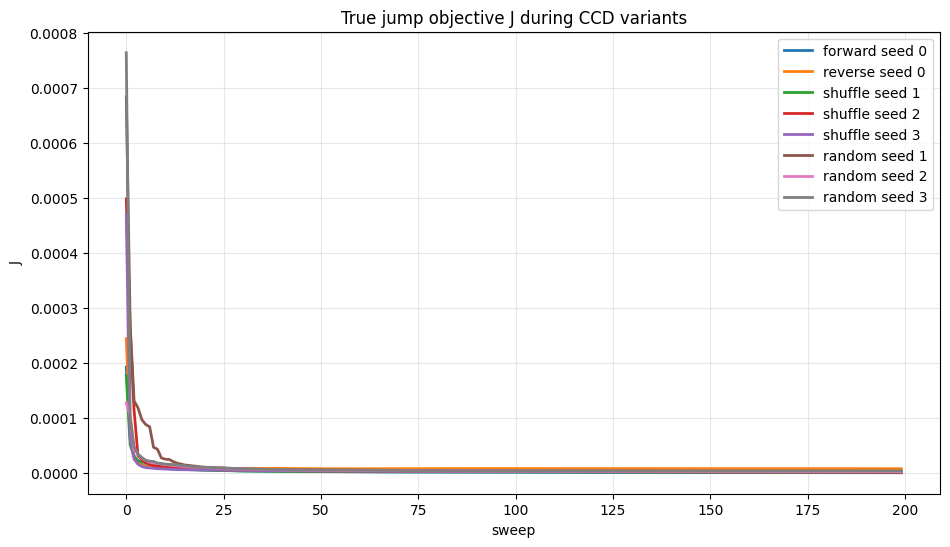

In [44]:

plt.figure(figsize=(11, 6))

for result in variant_results:
    label = result["method"] + " seed " + str(result["seed"])
    plt.plot(result["J_history"], linewidth=2, label=label)

plt.xlabel("sweep")
plt.ylabel("J")
plt.title("True jump objective J during CCD variants")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## Compare final time-value curves

The next plot overlays the final \(V(K)\) curves. If the curves are visually close and all remain inside the bid-ask band, then the CCD variants are reaching similar feasible LVG calibrations.


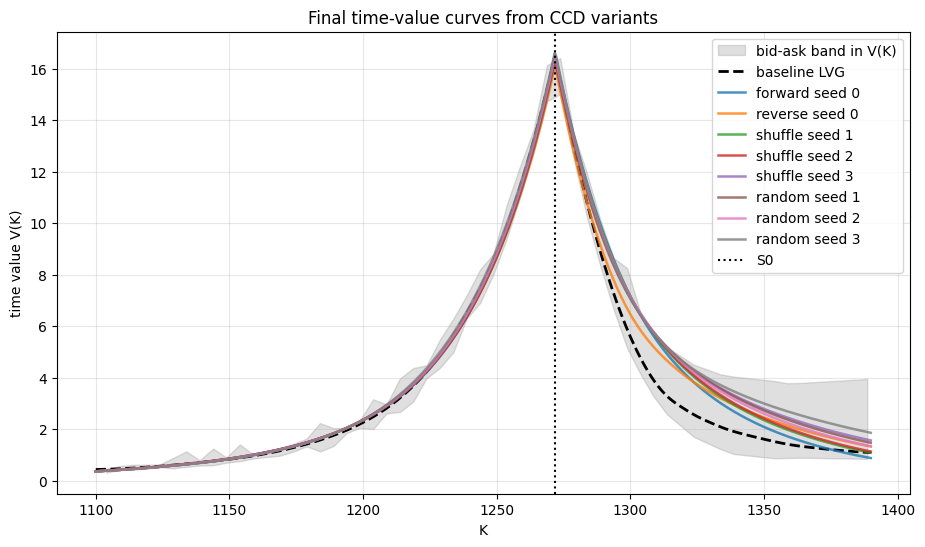

In [45]:

K_band, V_bid, V_ask = load_bid_ask_time_value_band("Quotes.csv", S0)
K_plot = np.linspace(1100, 1390, 700)

plt.figure(figsize=(11, 6))
plt.fill_between(K_band, V_bid, V_ask, color="gray", alpha=0.25, label="bid-ask band in V(K)")
plt.plot(K_plot, time_value_curve(init_theta, K_plot), color="black", linestyle="--", linewidth=2, label="baseline LVG")

for result in variant_results:
    label = result["method"] + " seed " + str(result["seed"])
    V_values = time_value_curve(result["theta"], K_plot)
    plt.plot(K_plot, V_values, linewidth=1.8, alpha=0.8, label=label)

plt.axvline(S0, color="black", linestyle=":", linewidth=1.5, label="S0")
plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Final time-value curves from CCD variants")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## Compare final sigma curves

This plot is the direct view of what CCD is changing. It shows the final piecewise diffusion coefficient \(\sigma\) for each variant.

A smoother sigma curve usually corresponds to fewer large jumps in \(C''\), but the relationship is not exact because \(C''\) also depends on the LVG coefficients and lambdas.


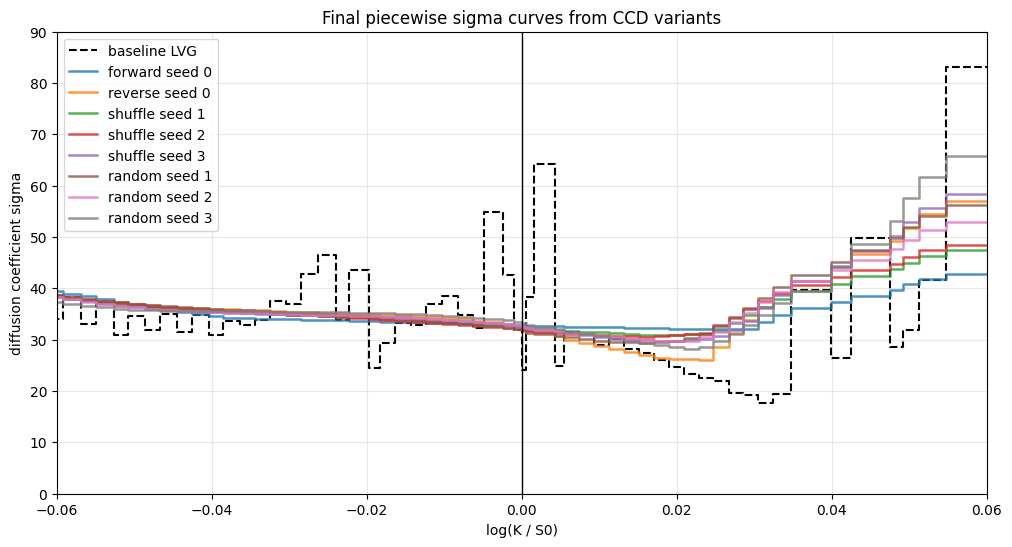

In [46]:

plt.figure(figsize=(12, 6))

x_base, y_base = sigma_step_data(init_theta)
plt.plot(x_base, y_base, color="black", linestyle="--", linewidth=1.5, label="baseline LVG")

for result in variant_results:
    label = result["method"] + " seed " + str(result["seed"])
    x_values, y_values = sigma_step_data(result["theta"])
    plt.plot(x_values, y_values, linewidth=1.8, alpha=0.8, label=label)

plt.axvline(0, color="black", linewidth=1)
plt.xlim(-0.06, 0.06)
plt.ylim(0, 90)
plt.xlabel("log(K / S0)")
plt.ylabel("diffusion coefficient sigma")
plt.title("Final piecewise sigma curves from CCD variants")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## This Notebook was created with codex

The point is that CCD gets a near 100% reduction in J by simplifying the objective and thus making it easier for the optimizer to get at the crux of irregularities in the smoothness. This basically confirms that the normal SciPy optimizer was getting stuck in some type of local minimum, or not working fast enough.  CCD is both fater and yields a significantly better result.

Furthermore, GD from that theta starting point only reduces J by another 4% with an extremely small improvement tolerance, suggesting that this sigma vector produces a local minimum for J. We can see in the graphs for V(K) that the forward CCD curve barely has any slack room left in the bid-ask band, which tells us this might be the global minimum for this data set, but we have no actual way of confirming this. 

When trying different methods of CCD, forward cycling through the sigmas worked better in terms of minimzing J and also worked faster. We still need to confirm this is the best method on other data sets, so that is the next natural step.